I0000 00:00:1773359185.927722   47783 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773359185.928863   47783 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773359186.036660   47783 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773359188.027544   47783 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

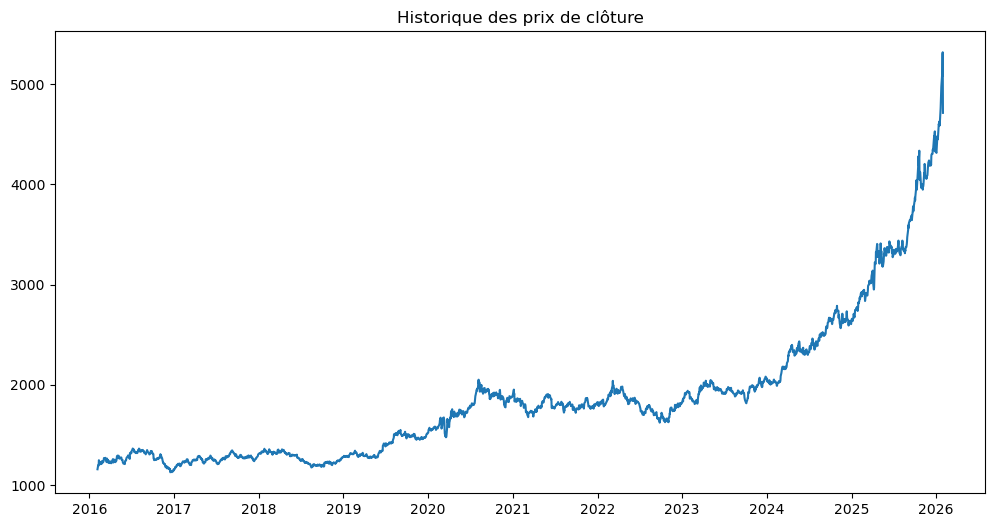

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Charger le dataset
df = pd.read_csv('dataset.csv')
df.columns = df.columns.str.strip()

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# Visualisation rapide
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title('Historique des prix de clôture')
plt.show()

In [2]:
# Sélection de la cible
data = df[['Close']].values

# Normalisation
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Séparation Train/Test (80% pour l'entraînement)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [3]:
def create_sequences(dataset, window_size=60):
    X, y = [], []
    for i in range(window_size, len(dataset)):
        X.append(dataset[i-window_size:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X_train, y_train = create_sequences(train_data, window_size)
X_test, y_test = create_sequences(test_data, window_size)

# Redimensionner pour LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [4]:
from tensorflow.keras.layers import Input # Importe Input

model = Sequential([
    Input(shape=(X_train.shape[1], 1)), # Définir l'entrée ici
    LSTM(units=50, return_sequences=True), # Plus besoin d'input_shape ici
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

E0000 00:00:1773359188.567090   47783 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
model.fit(X_train, y_train, batch_size=32, epochs=10)

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - loss: 0.0017
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 1.7184e-04
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 1.5202e-04
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 1.2490e-04
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 1.1211e-04
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 1.0479e-04
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 1.0571e-04
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 9.7822e-05
Epoch 9/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 1.0023e-04
Epoch 10/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 8.5891e-05


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
Mean Squared Error: 61831.56453226607


/tmp/ipykernel_47783/3484598626.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


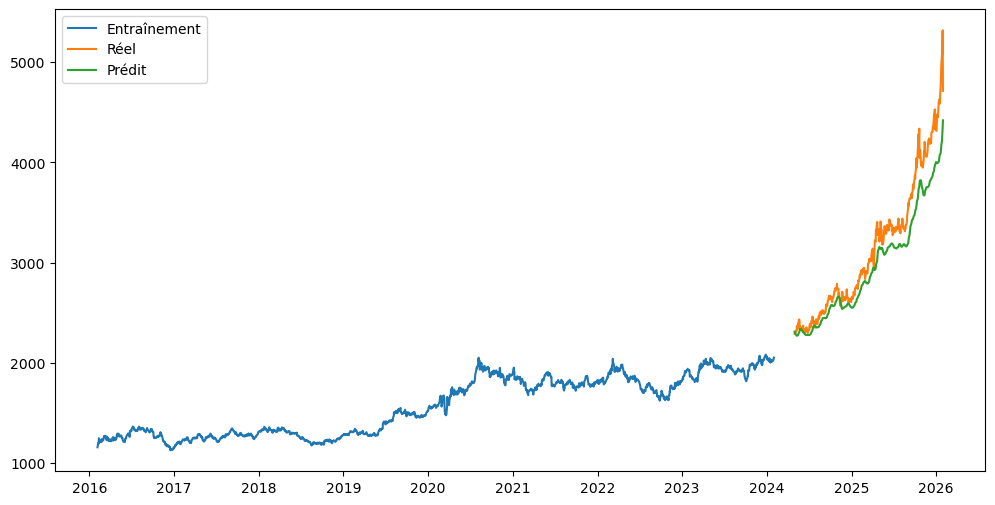

In [6]:
# Prédictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions) # Retour aux prix réels

# Calcul du MSE
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))
mse = np.mean((predictions - y_test_unscaled)**2)
print(f"Mean Squared Error: {mse}")

# Visualisation des résultats
train = df[:train_size]
valid = df[train_size + window_size:]
valid['Predictions'] = predictions

plt.figure(figsize=(12,6))
plt.plot(train['Close'], label='Entraînement')
plt.plot(valid[['Close', 'Predictions']], label=['Réel', 'Prédit'])
plt.legend()
plt.show()

In [7]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
